# Retail Demand Forecasting: A 4-Model Bake-Off

**Industry**: Retail
**Tools**: Python (statsmodels, Prophet, scikit-learn)

This notebook forecasts daily retail sales by comparing four approaches on a
common holdout period, from a naive baseline up to SARIMA and Prophet:

1. **Seasonal Naive** — baseline: repeat last week's pattern
2. **Holt-Winters Exponential Smoothing** — trend + weekly seasonality
3. **SARIMA** — small grid search over orders, selected by AIC on training data
4. **Prophet** — automatic trend/weekly/yearly seasonality decomposition

The winner is decided by holdout MAPE/RMSE, not assumed in advance.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from prophet import Prophet

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (12, 4)

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv("../data/daily_sales.csv", parse_dates=["date"])
df = df.set_index("date").asfreq("D")
print(df.shape)
df.head()

(1277, 2)


,sales,promo_flag
date,,
2022-01-01,"5,730.35",1
2022-01-02,"5,158.53",1
2022-01-03,"4,177.62",1
2022-01-04,"2,928.61",0
2022-01-05,"2,932.00",0


In [3]:
df.describe()

,sales,promo_flag
count,"1,277.00","1,277.00"
mean,"5,976.69",0.06
std,"2,069.21",0.25
min,"2,694.21",0.00
25%,"4,577.60",0.00
50%,"5,587.87",0.00
75%,"6,898.15",0.00
max,"19,302.98",1.00


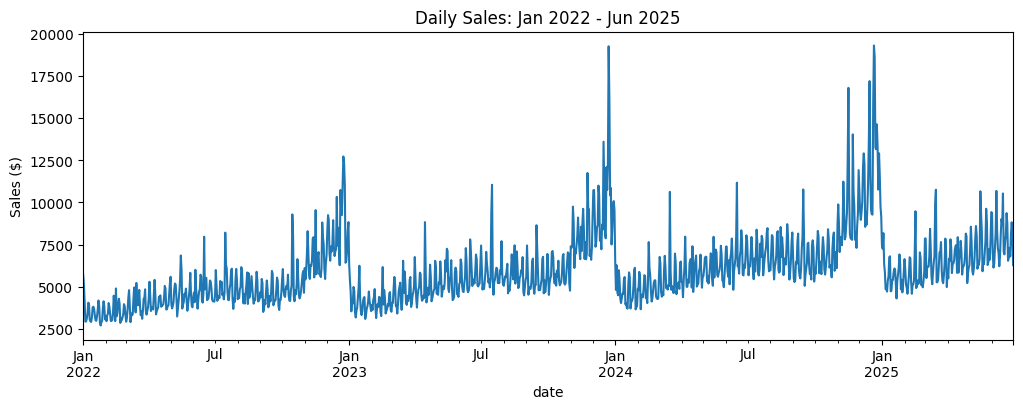

In [4]:
df["sales"].plot(title="Daily Sales: Jan 2022 - Jun 2025")
plt.ylabel("Sales ($)")
plt.show()

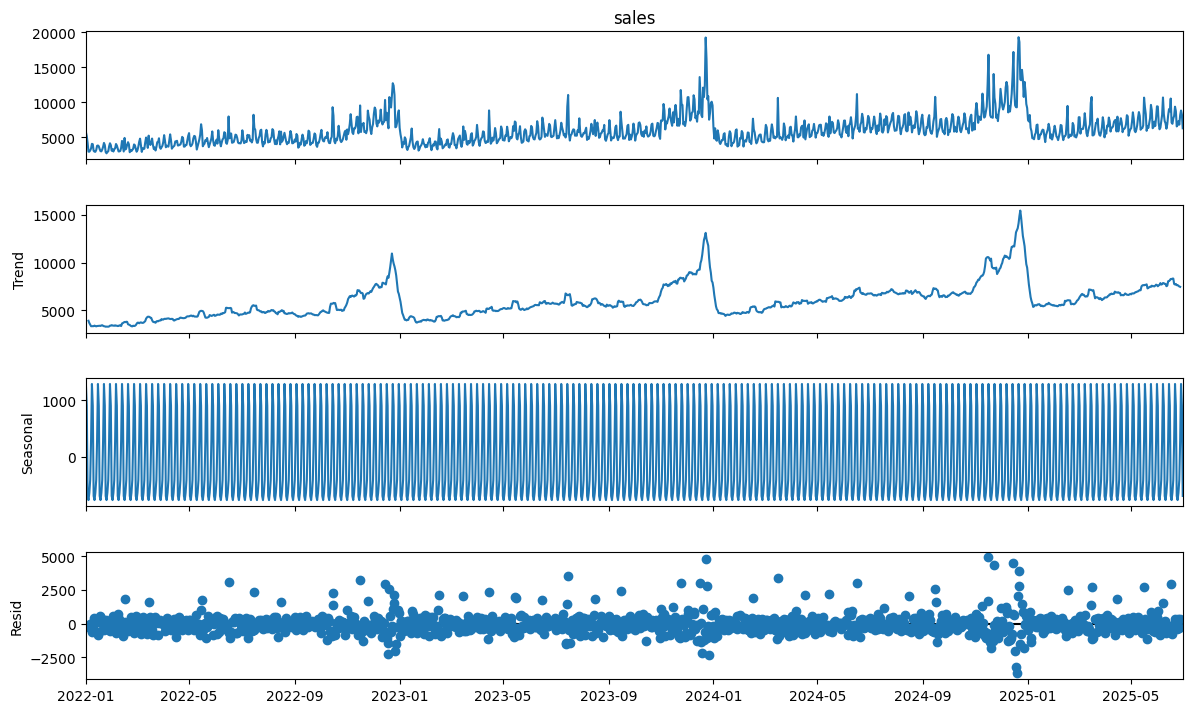

In [5]:
decomposition = seasonal_decompose(df["sales"], model="additive", period=7)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

**What this shows**: A clear upward trend (business growth), strong weekly
seasonality (weekend lift), and residual noise. Annual seasonality (Nov/Dec
peak) is visible in the raw series plot above but is not isolated by a
period=7 decomposition — Prophet will capture it natively later via its
yearly seasonality term.

## 2. Train/Test Split

In [6]:
HOLDOUT_DAYS = 90
train = df.iloc[:-HOLDOUT_DAYS]
test = df.iloc[-HOLDOUT_DAYS:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

Train: 2022-01-01 to 2025-04-01 (1187 days)
Test:  2025-04-02 to 2025-06-30 (90 days)


## 3. Model 1 — Seasonal Naive Baseline

In [7]:
last_cycle = train["sales"].values[-7:]
n_tiles = int(np.ceil(len(test) / 7))
seasonal_naive_fc = np.tile(last_cycle, n_tiles)[: len(test)]
seasonal_naive_fc = pd.Series(seasonal_naive_fc, index=test.index)

naive_mape = mean_absolute_percentage_error(test["sales"], seasonal_naive_fc) * 100
naive_rmse = mean_squared_error(test["sales"], seasonal_naive_fc) ** 0.5
print(f"Seasonal Naive -> MAPE: {naive_mape:.2f}% | RMSE: {naive_rmse:,.0f}")

Seasonal Naive -> MAPE: 14.96% | RMSE: 1,397


## 4. Model 2 — Holt-Winters Exponential Smoothing

In [8]:
hw_model = ExponentialSmoothing(
    train["sales"], trend="add", seasonal="add", seasonal_periods=7
).fit()
hw_fc = hw_model.forecast(len(test))

hw_mape = mean_absolute_percentage_error(test["sales"], hw_fc) * 100
hw_rmse = mean_squared_error(test["sales"], hw_fc) ** 0.5
print(f"Holt-Winters -> MAPE: {hw_mape:.2f}% | RMSE: {hw_rmse:,.0f}")

Holt-Winters -> MAPE: 10.70% | RMSE: 1,085


## 5. Model 3 — SARIMA

A small grid search over (p,d,q)(P,D,Q,7) combinations, selected by AIC on
**training data only** (no peeking at the test set), then evaluated on the
holdout.

In [9]:
orders = [(1, 1, 1), (2, 1, 1), (1, 1, 2), (0, 1, 1)]
seasonal_orders = [(0, 1, 1, 7), (1, 1, 0, 7), (1, 1, 1, 7)]

best_aic = np.inf
best_order = None
best_seasonal_order = None

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(
                train["sales"], order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False,
            )
            fit = model.fit(disp=False)
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = order
                best_seasonal_order = seasonal_order
        except Exception:
            continue

print(f"Best order: {best_order}{best_seasonal_order} | AIC: {best_aic:.1f}")

/home/gichuki/myenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best order: (1, 1, 1)(1, 1, 1, 7) | AIC: 19263.7


In [10]:
sarima_model = SARIMAX(
    train["sales"], order=best_order, seasonal_order=best_seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

sarima_fc = sarima_model.get_forecast(steps=len(test)).predicted_mean
sarima_fc.index = test.index

sarima_mape = mean_absolute_percentage_error(test["sales"], sarima_fc) * 100
sarima_rmse = mean_squared_error(test["sales"], sarima_fc) ** 0.5
print(f"SARIMA{best_order}{best_seasonal_order} -> MAPE: {sarima_mape:.2f}% | RMSE: {sarima_rmse:,.0f}")

SARIMA(1, 1, 1)(1, 1, 1, 7) -> MAPE: 14.00% | RMSE: 1,330


## 6. Model 4 — Prophet

In [11]:
prophet_train = train.reset_index().rename(columns={"date": "ds", "sales": "y"})

prophet_model = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test))
prophet_full_fc = prophet_model.predict(future)
prophet_fc = prophet_full_fc.set_index("ds").loc[test.index, "yhat"]

prophet_mape = mean_absolute_percentage_error(test["sales"], prophet_fc) * 100
prophet_rmse = mean_squared_error(test["sales"], prophet_fc) ** 0.5
print(f"Prophet -> MAPE: {prophet_mape:.2f}% | RMSE: {prophet_rmse:,.0f}")

13:47:37 - cmdstanpy - INFO - Chain [1] start processing


13:47:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet -> MAPE: 6.88% | RMSE: 719


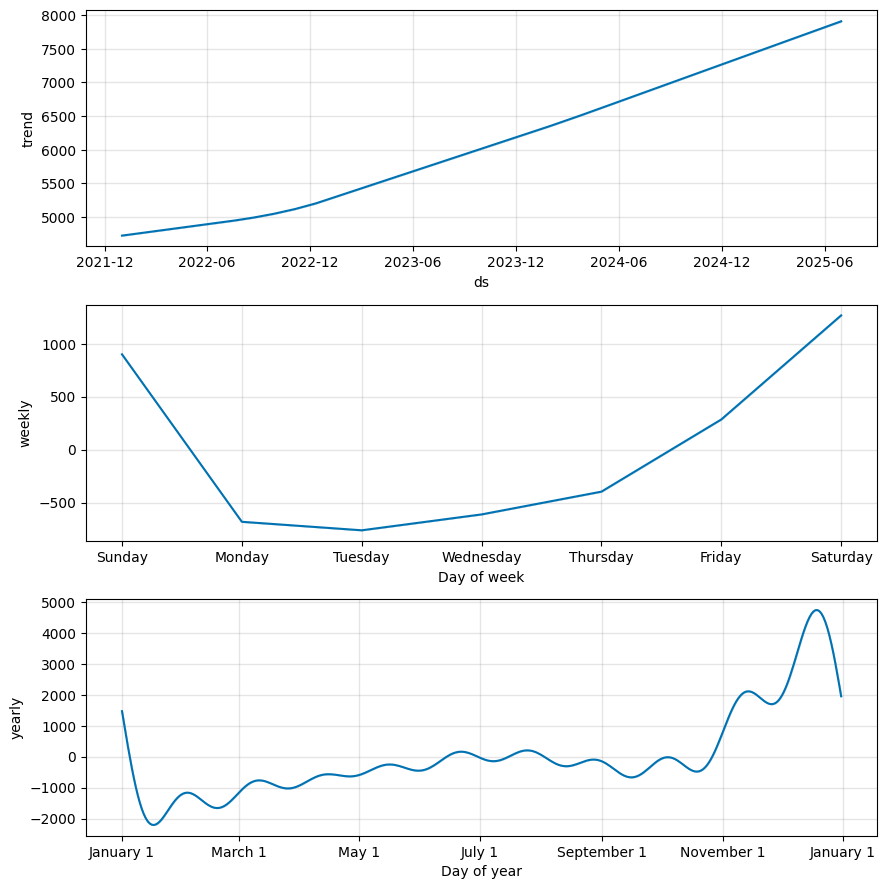

In [12]:
fig = prophet_model.plot_components(prophet_full_fc)
plt.show()

## 7. Model Comparison

In [13]:
results = pd.DataFrame([
    {"model": "Seasonal Naive", "mape_pct": naive_mape, "rmse": naive_rmse},
    {"model": "Holt-Winters", "mape_pct": hw_mape, "rmse": hw_rmse},
    {"model": f"SARIMA{best_order}{best_seasonal_order}", "mape_pct": sarima_mape, "rmse": sarima_rmse},
    {"model": "Prophet", "mape_pct": prophet_mape, "rmse": prophet_rmse},
]).sort_values("mape_pct").reset_index(drop=True)

results

,model,mape_pct,rmse
0,Prophet,6.88,719.14
1,Holt-Winters,10.70,"1,084.84"
2,"SARIMA(1, 1, 1)(1, 1, 1, 7)",14.00,"1,329.99"
3,Seasonal Naive,14.96,"1,397.46"


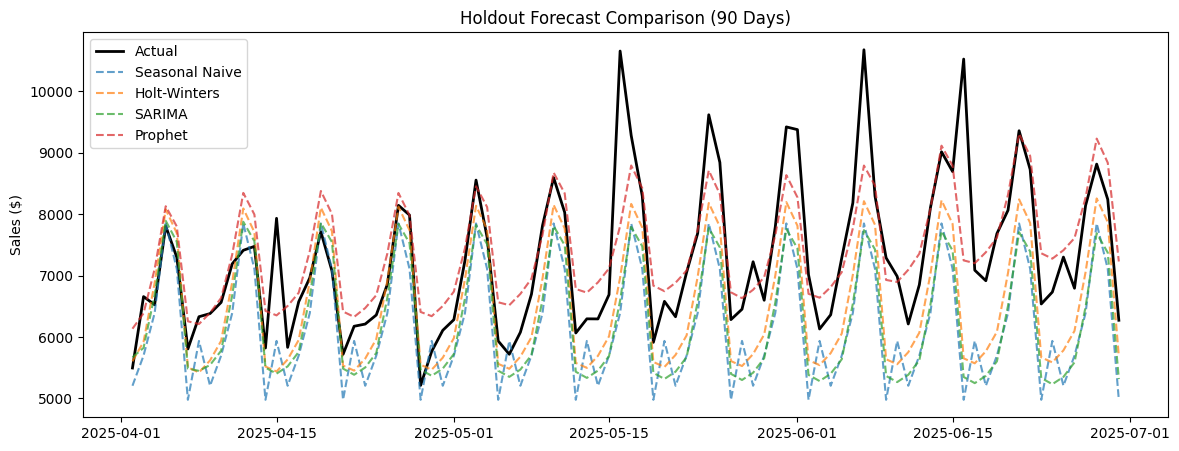

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(test.index, test["sales"], label="Actual", color="black", linewidth=2)
plt.plot(test.index, seasonal_naive_fc, label="Seasonal Naive", linestyle="--", alpha=0.7)
plt.plot(test.index, hw_fc, label="Holt-Winters", linestyle="--", alpha=0.7)
plt.plot(test.index, sarima_fc, label="SARIMA", linestyle="--", alpha=0.7)
plt.plot(test.index, prophet_fc, label="Prophet", linestyle="--", alpha=0.7)
plt.title("Holdout Forecast Comparison (90 Days)")
plt.ylabel("Sales ($)")
plt.legend()
plt.show()

## 8. Conclusion

The model comparison table above (re-run to view current numbers) determines
the winner on this dataset by holdout MAPE — see the project README for the
specific result and business recommendation derived from it.